### ROSALIA Paper I: Getting the Segments to simulate stray-light from the April2026 Mission Plan
First version: August 4, 2026. 

Alejandro S. Borlaff - NASA Ames Research Center. 
STA N245-312 - a.s.borlaff@nasa.gov


In [20]:
import os
import numpy as np
from tqdm import tqdm
import rosalia as rs
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord  # High-level coordinates
plt.style.use(os.path.dirname(rs.__file__) + "/style/nature_style.mplstyle")


In [21]:
def find_exposures_from_mission_plan(visit_id):
    """
    Find the exposures from the mission plan that correspond to a given segment ID.
    """    
    # row = mission_plan[mission_plan["visit-id"] == visit_id]

    program_id = visit_id[0:5]
    plan_id = visit_id[5:7]
    pass_id = visit_id[7:10]
    segment_id = visit_id[10:13]

    match program_id:
        case "00981":
            print("GPS")
            program_plan_name = "/Users/aborlaff/NASA/ROSALIA_DEPOT/Apr2026_MissionPlan/APT_csv/981-gps-Feb26.sim.ecsv"
        case "00994":
            print("HLWAS")
            program_plan_name = "/Users/aborlaff/NASA/ROSALIA_DEPOT/Apr2026_MissionPlan/APT_csv/994-hlwas-Feb26.sim.ecsv"
        case "00998":
            print("GBTDS")
            program_plan_name = "/Users/aborlaff/NASA/ROSALIA_DEPOT/Apr2026_MissionPlan/APT_csv/998-gbtds-Feb26.sim.ecsv"
        case "00999":
            print("HLTDS")
            program_plan_name = "/Users/aborlaff/NASA/ROSALIA_DEPOT/Apr2026_MissionPlan/APT_csv/999-hltds-Feb26.sim.ecsv"

    program_plan = pd.read_csv(program_plan_name, comment="#", sep="\s",skiprows=1)

    # Find the requested exposures. 
    program_plan = program_plan[program_plan["SEGMENT"] == int(segment_id)]
    program_plan = program_plan[program_plan["PLAN"] == int(plan_id)]
    program_plan = program_plan[program_plan["PASS"] == int(pass_id)]

    return(program_plan)


def pick_n_exposures_from_program_plan(n, program_plan, program_id):

    # Remove GRISM observations from analysis. 
    program_plan = program_plan[program_plan["BANDPASS"] != "GRISM"]
    program_plan = program_plan.reset_index(drop=True)

    ids = np.random.choice(program_plan.index, size=len(program_plan.index), replace=False)
    mission_visit_ids = []
    mission_plan_rows = []
    count = 0 

    with tqdm(total = n) as pbar:
        while count < n:
            i = ids[count]
            mission_visit_id = program_id + str(program_plan.iloc[i]["PLAN"]).zfill(2) + str(program_plan.iloc[i]["PASS"]).zfill(3) + str(program_plan.iloc[i]["SEGMENT"]).zfill(3)
            mission_plan_row = mission_plan[mission_plan["visit-id"] == mission_visit_id]
        
            if len(mission_plan_row) == 0:
                print(mission_visit_id)
                print(program_plan.iloc[i])
                
            else: 
                count = count + 1 
                mission_visit_ids.append(mission_visit_id)
                mission_plan_rows.append(mission_plan_row)

            print(count)
            pbar.update(1)

    mission_plan_rows = pd.concat(mission_plan_rows)

    # print(mission_plan_rows["assigned orient"])

    exposures_db = program_plan.loc[ids]
    exposures_db = exposures_db.reset_index(drop=True)
    exposures_db["PA"] = np.array(mission_plan_rows["assigned orient"])

    # print(mission_visit_ids)
    exposures_db["MissionPlanID"] = mission_visit_ids

    return(exposures_db)


##### Let's select the segments to simulate from the Roman Mission Plan
We will use the Simulated_schedules from Apr2026_MissionPlan, in STScI BOX (POC: Gisela de Rosa)

In [22]:
mission_plan = pd.read_csv("/Users/aborlaff/NASA/ROSALIA_DEPOT/Apr2026_MissionPlan/schedule-RD26075MP1-run_id_RD26075MP1_R26069HJROLLP1.csv", dtype={"visit-id": str})
mission_plan

,visit-id,duration,assigned orient,nominal orient,ra,dec,start,end,slew,gap
0,0099401110003,8460.0,238.346555,229.747368,6.277555,-0.409579,2026.362:00:00:00,2026.362:02:21:38,NaN,NaN
1,0099401110002,8460.0,238.346555,230.083962,6.274454,-0.450719,2026.362:02:27:32,2026.362:04:49:10,354.0,0.0
2,0099401110001,8460.0,238.346555,230.528016,6.271035,-0.491781,2026.362:04:55:04,2026.362:07:16:43,354.0,0.0
3,0099401125029,8784.0,224.163754,234.886134,0.178414,-0.703647,2026.362:07:22:37,2026.362:09:50:09,354.0,0.0
4,0099401125027,8784.0,224.163754,236.088408,0.178822,-0.786049,2026.362:09:56:03,2026.362:12:23:36,354.0,0.0
...,...,...,...,...,...,...,...,...,...,...
8522,0099401135094,8460.0,105.561934,109.771101,2.825008,-0.232616,2031.335:01:28:31,2031.335:03:50:09,354.0,0.0
8523,0099401135101,8460.0,105.561934,109.206855,2.866467,-0.315416,2031.336:18:00:00,2031.336:20:21:38,354.0,137036.0
8524,0099401135102,8460.0,105.561934,109.799462,2.867053,-0.274232,2031.336:20:27:32,2031.336:22:49:10,354.0,0.0
8525,0099401135111,8460.0,105.561934,110.202123,2.909910,-0.315653,2031.339:18:00:00,2031.339:20:21:38,354.0,241495.0


Text(0, 0.5, 'Dec [deg]')

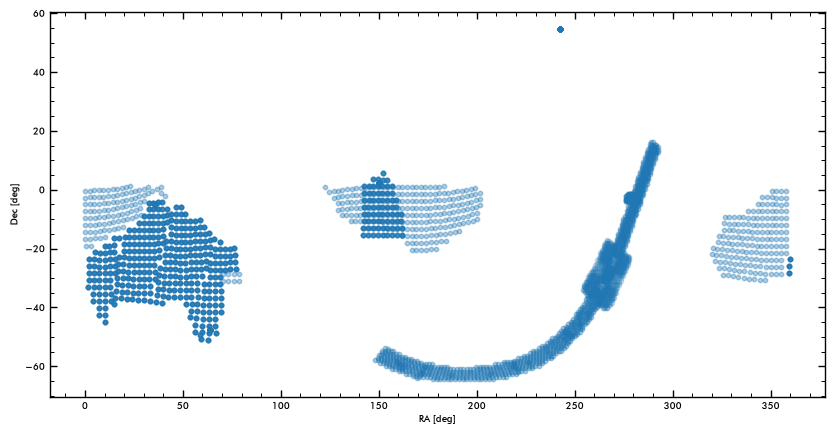

In [23]:
visit_coords = SkyCoord(np.rad2deg(mission_plan["ra"]), np.rad2deg(mission_plan["dec"]), frame="icrs", unit=(u.deg, u.deg))  # 3 coords

fig, ax = plt.subplots(figsize=(10,5))
ax.scatter(visit_coords.ra, visit_coords.dec, s=10, alpha=0.2)
ax.set_xlabel("RA [deg]")
ax.set_ylabel("Dec [deg]")

In [24]:
visit_id = "0099801051001" # "0099401135010" # 0099801051001
find_exposures_from_mission_plan(visit_id=visit_id)


GBTDS


KeyboardInterrupt: 

In [ ]:
gps_program_id = "00981"
gps_program_plan_name = "/Users/aborlaff/NASA/ROSALIA_DEPOT/Apr2026_MissionPlan/APT_csv/981-gps-Feb26.sim.ecsv"
gps_program_plan = pd.read_csv(gps_program_plan_name, comment="#", sep="\s", skiprows=1)

hlwas_program_id = "00994"
hlwas_program_plan_name = "/Users/aborlaff/NASA/ROSALIA_DEPOT/Apr2026_MissionPlan/APT_csv/994-hlwas-Feb26.sim.ecsv"
hlwas_program_plan = pd.read_csv(hlwas_program_plan_name, comment="#", sep="\s", skiprows=1)

gbtds_program_id = "00998"
gbtds_program_plan_name = "/Users/aborlaff/NASA/ROSALIA_DEPOT/Apr2026_MissionPlan/APT_csv/998-gbtds-Feb26.sim.ecsv"
gbtds_program_plan = pd.read_csv(gbtds_program_plan_name, comment="#", sep="\s", skiprows=1)

hltds_program_id = "00999"
hltds_program_plan_name = "/Users/aborlaff/NASA/ROSALIA_DEPOT/Apr2026_MissionPlan/APT_csv/999-hltds-Feb26.sim.ecsv"
hltds_program_plan = pd.read_csv(hltds_program_plan_name, comment="#", sep="\s", skiprows=1)




In [ ]:
# Get the exposures 
n = 1000
gps_mission_exposures   = pick_n_exposures_from_program_plan(n=n, program_plan=gps_program_plan,   program_id=gps_program_id)
hlwas_mission_exposures = pick_n_exposures_from_program_plan(n=n, program_plan=hlwas_program_plan, program_id=hlwas_program_id)
gbtds_mission_exposures = pick_n_exposures_from_program_plan(n=n, program_plan=gbtds_program_plan, program_id=gbtds_program_id)
hltds_mission_exposures = pick_n_exposures_from_program_plan(n=n, program_plan=hltds_program_plan, program_id=hltds_program_id)


 18%|█▊        | 180/1000 [00:00<00:00, 902.64it/s]

1
2
3
4
5
6
0098101016029
RA                  263.254547
DEC                 -27.620345
PA                         0.0
BANDPASS                  F129
MA_TABLE_NUMBER           1001
DURATION                   136
PLAN                         1
PASS                        16
SEGMENT                     29
OBSERVATION                  1
VISIT                        1
EXPOSURE                     2
EXPOSURE_TIME         60.08694
TARGET_NAME        Bulge2_Bpos
Name: 16657, dtype: object
6
0098101016029
RA                  263.254547
DEC                 -27.620345
PA                         0.0
BANDPASS                  F129
MA_TABLE_NUMBER           1001
DURATION                   136
PLAN                         1
PASS                        16
SEGMENT                     29
OBSERVATION                  1
VISIT                        1
EXPOSURE                     2
EXPOSURE_TIME         60.08694
TARGET_NAME        Bulge2_Bpos
Name: 16657, dtype: object
6
0098101016029
RA                  

 27%|██▋       | 271/1000 [00:00<00:00, 775.54it/s]

0098101016029
RA                  263.254547
DEC                 -27.620345
PA                         0.0
BANDPASS                  F129
MA_TABLE_NUMBER           1001
DURATION                   136
PLAN                         1
PASS                        16
SEGMENT                     29
OBSERVATION                  1
VISIT                        1
EXPOSURE                     2
EXPOSURE_TIME         60.08694
TARGET_NAME        Bulge2_Bpos
Name: 16657, dtype: object
6
0098101016029
RA                  263.254547
DEC                 -27.620345
PA                         0.0
BANDPASS                  F129
MA_TABLE_NUMBER           1001
DURATION                   136
PLAN                         1
PASS                        16
SEGMENT                     29
OBSERVATION                  1
VISIT                        1
EXPOSURE                     2
EXPOSURE_TIME         60.08694
TARGET_NAME        Bulge2_Bpos
Name: 16657, dtype: object
6
0098101016029
RA                  263.254547
D

 44%|████▍     | 441/1000 [00:00<00:00, 800.09it/s]

...

11696it [00:14, 722.86it/s]

0098101016029
RA                  263.254547
DEC                 -27.620345
PA                         0.0
BANDPASS                  F129
MA_TABLE_NUMBER           1001
DURATION                   136
PLAN                         1
PASS                        16
SEGMENT                     29
OBSERVATION                  1
VISIT                        1
EXPOSURE                     2
EXPOSURE_TIME         60.08694
TARGET_NAME        Bulge2_Bpos
Name: 16657, dtype: object
6
0098101016029
RA                  263.254547
DEC                 -27.620345
PA                         0.0
BANDPASS                  F129
MA_TABLE_NUMBER           1001
DURATION                   136
PLAN                         1
PASS                        16
SEGMENT                     29
OBSERVATION                  1
VISIT                        1
EXPOSURE                     2
EXPOSURE_TIME         60.08694
TARGET_NAME        Bulge2_Bpos
Name: 16657, dtype: object
6
0098101016029
RA                  263.254547
D

11816it [00:14, 788.71it/s]


0098101016029
RA                  263.254547
DEC                 -27.620345
PA                         0.0
BANDPASS                  F129
MA_TABLE_NUMBER           1001
DURATION                   136
PLAN                         1
PASS                        16
SEGMENT                     29
OBSERVATION                  1
VISIT                        1
EXPOSURE                     2
EXPOSURE_TIME         60.08694
TARGET_NAME        Bulge2_Bpos
Name: 16657, dtype: object
6
0098101016029
RA                  263.254547
DEC                 -27.620345
PA                         0.0
BANDPASS                  F129
MA_TABLE_NUMBER           1001
DURATION                   136
PLAN                         1
PASS                        16
SEGMENT                     29
OBSERVATION                  1
VISIT                        1
EXPOSURE                     2
EXPOSURE_TIME         60.08694
TARGET_NAME        Bulge2_Bpos
Name: 16657, dtype: object
6
0098101016029
RA                  263.254547
D

KeyboardInterrupt: 

In [ ]:
# Let's plot the location in the sky of the survey. 

fig, ax = plt.subplots(figsize=(6,6))

ax.scatter(HLWAS_77_coords.ra.value, HLWAS_77_coords.dec.value, alpha=0.5, marker="s", facecolor="dodgerblue", color="black", label="HWLAS pointing")
ax.scatter(HLWAS_167_coords.ra.value, HLWAS_167_coords.dec.value, alpha=0.5, marker="s", facecolor="dodgerblue", color="black")
ax.scatter(HLWAS_243_coords.ra.value, HLWAS_243_coords.dec.value, alpha=0.5, marker="s", facecolor="dodgerblue", color="black")

ax.set_xlabel("Right ascension (degrees)")
ax.set_ylabel("Declination (degrees)")
plt.legend(frameon=False)
plt.savefig("HWLAS_coords.png", dpi=300)
import numpy as np
median_ra = np.median(np.array(list(HLWAS_77_coords.ra.value) + list(HLWAS_167_coords.ra.value) + list(HLWAS_243_coords.ra.value)))
median_dec = np.median(np.array(list(HLWAS_77_coords.dec.value) + list(HLWAS_167_coords.dec.value) + list(HLWAS_243_coords.dec.value)))

HLWAS_median  = SkyCoord(median_ra, median_dec, frame="icrs", unit=(u.deg))  # 3 coords

# ax.scatter(HLWAS_median.ra.value, HLWAS_median.dec.value, alpha=1, marker="+", s=1000, color="red")


In [ ]:
# Let's simulate the stray-light on random positions across the survey. 

# First, we need to find the correct position angle for the images.  
# We can generate these easily using Romanisim 
# https://roman-crds.stsci.edu/static/users_guide/basic_use.html

prefix_name = "ROSALIA_HLWAS_SCA"
bandpass = "F146"

# A likely date to obtain the images 
from astropy.time import Time
date = Time('2027-06-21T00:00:00.0', format='isot', scale='utc')

# Let's focus on one group of images. HLWAS 77 degrees. 


PA_v3 = np.zeros(len(HLWAS_77_coords))

from tqdm import tqdm 
for i in tqdm(range(len(PA_v3))):
    PA_v3[i] = rs.telescopes.Roman.get_bestPA(ra=HLWAS_77_coords[i].ra.value, dec=HLWAS_77_coords[i].dec.value, mjd=date.mjd)


In [ ]:

###################################
# This step takes time
# We will run it on a if bracket to avoid re-running if the images are already on the disk.
############
import os
import glob 

for i in range(len(PA_v3)):
    ra = HLWAS_77_coords[i].ra.value
    dec = HLWAS_77_coords[i].dec.value
    pa = PA_v3[i]
    mjd = date.mjd
    bandpass="F129"
    exptime=600
    rosalia_stray = rs.correct.rosalia_stray(ra=ra, dec=dec, 
                                             PA=pa, date=date, prefix="HWLAS77_", bandpass=bandpass, 
                                             exptime=exptime, radius=1,
                                             g_mag_max=20)

In [ ]:
# Get the images from the HLWAS 
import glob
import os
import numpy as np
import rosalia as rs
HLWAS_stray_names = glob.glob("HWLAS77_WFI_F129_*_stray_drz_scaled.fits")
print(HLWAS_stray_names)

import matplotlib.pyplot as plt
from astropy.io import fits
i = 0 

fig, ax = plt.subplots(figsize=(5,4))

mu_all = np.array([])
for i in range(len(HLWAS_stray_names)):
#if True:
    fe = fits.open(HLWAS_stray_names[i])[1].data
    mu = rs.detectors.fe2mu(fe, telescope="Roman", instrument="WFI", filter_name="F129")

mu_all = np.concatenate([mu_all, mu.flatten()])

ax.hist(mu_all, alpha=0.5, linewidth=1.5, color="dodgerblue", edgecolor="black", bins=500, density=True)

ax.set_xlabel(r'HLWAS Stray-light surface brightness (mag arcsec$^{-2}$)')
ax.set_ylabel(r'Density')
ax.set_xlim(28.2, 29)
plt.savefig("HWLAS_straylight_hist.png", dpi=300)



In [ ]:


for i in range(len(HLWAS_stray_names)):
    fe2mu_png = rs.plots.make_stray_plot(input_name=HLWAS_stray_names[i],
                                         ext=1, mode="fe2mu",
                                         color_label = "Surface brightness (mag arcsec$^{-2}$)", 
                                         figsize=(7,6), cmap="RdYlBu",
                                         mu_vmin=28.0, 
                                         mu_vmax=29.0)
